# End-to-End ML Pipeline on Tesla Sales and Production Data

## Objective

The goal of this project is to build a simple end-to-end machine learning pipeline using Tesla deliveries and production data from 2015 to 2025.

In this notebook, `Estimated_Deliveries` is the target column.

This is a supervised regression problem because the target is a continuous numeric value.

The project includes:
- Data cleaning
- Exploratory Data Analysis
- Feature engineering
- Regression modeling
- Hyperparameter tuning
- Time series forecasting

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Dataset Loading

The Tesla dataset has information about deliveries, production units, average price, battery capacity, range, region, vehicle model and charging stations.

In [2]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")
print("Shape:", df.shape)
df.head()

Shape: (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [3]:
assert df.shape[0] > 0, "Dataset is empty"
assert df.shape[1] > 0, "Dataset has no columns"
print("Dataset loaded successfully.")

Dataset loaded successfully.


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   str    
 3   Model                 2640 non-null   str    
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   str    
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), str(3)
memory usage: 247.6 KB


In [5]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [6]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

## Data Cleaning

Here I cleaned column names, removed duplicates, created a date column and sorted the dataset by time.

In [7]:
df.columns = df.columns.str.strip()

for col in ["Region", "Model", "Source_Type"]:
    df[col] = df[col].astype(str).str.strip()

df = df.drop_duplicates()
df = df[df["Month"].between(1, 12)]

df["Date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" + df["Month"].astype(str) + "-01"
)

df = df.sort_values(["Date", "Region", "Model"]).reset_index(drop=True)

print("Cleaned shape:", df.shape)
df.head()

Cleaned shape: (2640, 13)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2015,1,Asia,Cybertruck,11325,11887,54449.08,60,339,575.88,Estimated (Region),6902,2015-01-01
1,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01
2,2015,1,Asia,Model S,9537,10093,68994.43,82,484,692.39,Official (Quarter),7281,2015-01-01
3,2015,1,Asia,Model X,7292,7298,107082.30,120,702,767.85,Estimated (Region),11748,2015-01-01
4,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01


## Reflection

The dataset is structured and has both numerical and categorical variables.

The target variable for prediction is `Estimated_Deliveries`.

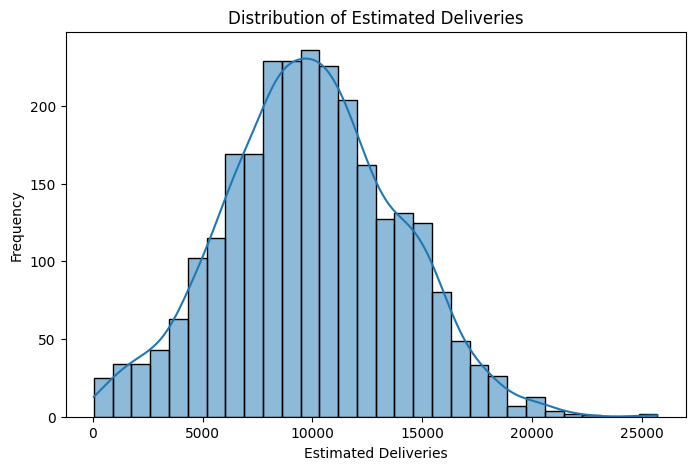

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Estimated_Deliveries"], bins=30, kde=True)
plt.title("Distribution of Estimated Deliveries")
plt.xlabel("Estimated Deliveries")
plt.ylabel("Frequency")
plt.show()

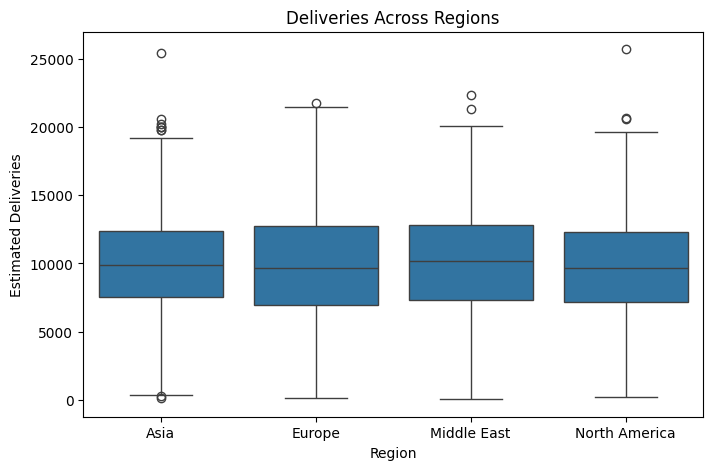

In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Region", y="Estimated_Deliveries")
plt.title("Deliveries Across Regions")
plt.xlabel("Region")
plt.ylabel("Estimated Deliveries")
plt.show()

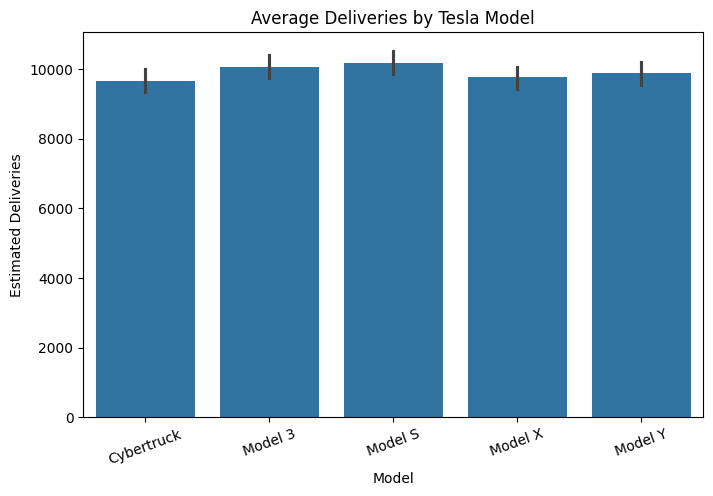

In [10]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Model", y="Estimated_Deliveries")
plt.title("Average Deliveries by Tesla Model")
plt.xlabel("Model")
plt.ylabel("Estimated Deliveries")
plt.xticks(rotation=20)
plt.show()

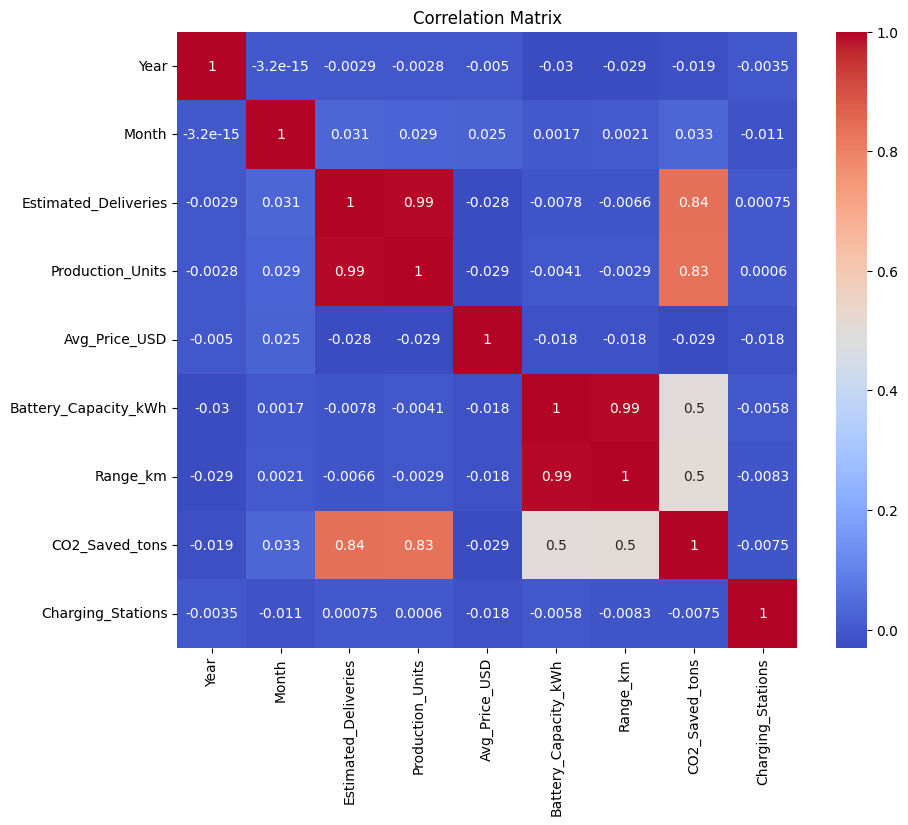

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

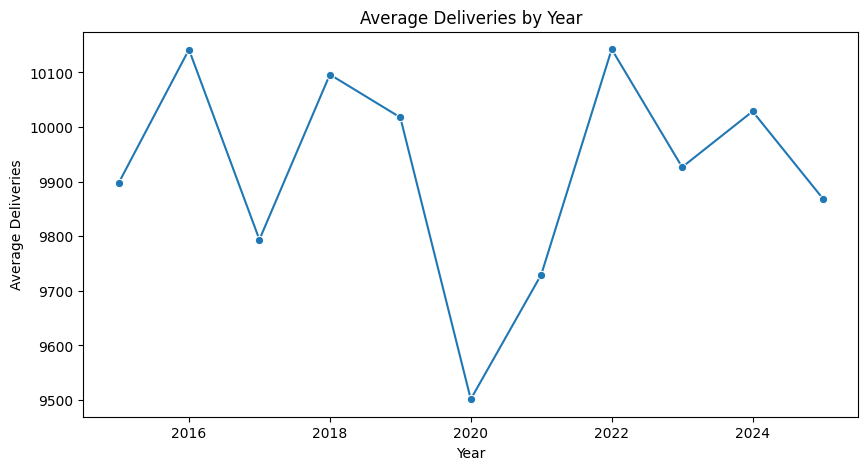

In [12]:
yearly = df.groupby("Year")["Estimated_Deliveries"].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=yearly, x="Year", y="Estimated_Deliveries", marker="o")
plt.title("Average Deliveries by Year")
plt.xlabel("Year")
plt.ylabel("Average Deliveries")
plt.show()

## EDA Findings

Production units are highly related to deliveries. Deliveries are also different for each region and model.

Average price and charging stations are useful business features.

## Feature Engineering

I created month seasonality features, lag features and rolling statistics.

Lag and rolling features are made using previous values, so future delivery values are not used.

I did not use `CO2_Saved_tons` in the model because it may be calculated from deliveries and can cause data leakage.

In [13]:
df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)

df["Lagged_Deliveries"] = (
    df.groupby(["Region", "Model"])["Estimated_Deliveries"].shift(1)
)

df["Rolling_Mean_3"] = (
    df.groupby(["Region", "Model"])["Estimated_Deliveries"]
      .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

df["Rolling_Std_3"] = (
    df.groupby(["Region", "Model"])["Estimated_Deliveries"]
      .transform(lambda x: x.shift(1).rolling(3, min_periods=2).std())
)

df["Price_per_km"] = df["Avg_Price_USD"] / df["Range_km"]

df[["Date", "Region", "Model", "Estimated_Deliveries", "Lagged_Deliveries", "Rolling_Mean_3"]].head(10)

,Date,Region,Model,Estimated_Deliveries,Lagged_Deliveries,Rolling_Mean_3
0,2015-01-01,Asia,Cybertruck,11325,NaN,NaN
1,2015-01-01,Asia,Model 3,8795,NaN,NaN
2,2015-01-01,Asia,Model S,9537,NaN,NaN
3,2015-01-01,Asia,Model X,7292,NaN,NaN
4,2015-01-01,Asia,Model Y,12446,NaN,NaN
5,2015-01-01,Europe,Cybertruck,2161,NaN,NaN
6,2015-01-01,Europe,Model 3,7597,NaN,NaN
7,2015-01-01,Europe,Model S,4350,NaN,NaN
8,2015-01-01,Europe,Model X,8833,NaN,NaN
9,2015-01-01,Europe,Model Y,10835,NaN,NaN


In [14]:
assert "Lagged_Deliveries" in df.columns
assert "Rolling_Mean_3" in df.columns
assert "Price_per_km" in df.columns
print("Feature engineering completed.")

Feature engineering completed.


In [15]:
target = "Estimated_Deliveries"

numerical_features = [
    "Year",
    "Month",
    "Month_sin",
    "Month_cos",
    "Production_Units",
    "Avg_Price_USD",
    "Battery_Capacity_kWh",
    "Range_km",
    "Charging_Stations",
    "Lagged_Deliveries",
    "Rolling_Mean_3",
    "Rolling_Std_3",
    "Price_per_km"
]

categorical_features = ["Region", "Model", "Source_Type"]

X = df[numerical_features + categorical_features]
y = df[target]

## Preprocessing Pipeline

Numerical columns are filled and scaled.

Categorical columns are filled and encoded.

This uses `Pipeline` and `ColumnTransformer`.

In [16]:
try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore")

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", encoder)
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


## Chronological Train-Test Split

For time series data, random splitting is avoided. I used the older months for training and newer months for testing.

In [17]:
unique_dates = np.array(sorted(df["Date"].unique()))
split_date = pd.Timestamp(unique_dates[int(len(unique_dates) * 0.8)])

train_mask = df["Date"] < split_date
test_mask = df["Date"] >= split_date

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]
y_train = y.loc[train_mask]
y_test = y.loc[test_mask]

print("Split date:", split_date)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Split date: 2023-10-01 00:00:00
Train shape: (2100, 16)
Test shape: (540, 16)


## Regression Models

I trained three supervised regression models:

- Linear Regression
- Ridge Regression (L2)
- Lasso Regression (L1)

In [18]:
def calculate_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred)
    }

In [19]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1),
    "Lasso Regression": Lasso(alpha=0.01, max_iter=20000)
}

results = []
trained_models = {}
predictions = {}

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipeline.fit(X_train, y_train)
    pred = pipeline.predict(X_test)
    
    trained_models[name] = pipeline
    predictions[name] = pred
    
    row = {"Model": name}
    row.update(calculate_metrics(y_test, pred))
    results.append(row)

results_df = pd.DataFrame(results).sort_values("RMSE")
results_df

,Model,MAE,MSE,RMSE,R2
1,Ridge Regression,354.295996,184839.906674,429.930118,0.986194
2,Lasso Regression,354.290081,184879.985003,429.976726,0.986191
0,Linear Regression,354.311163,184893.965597,429.992983,0.986190


## Bias-Variance, Overfitting and Underfitting

If a model is too simple, it can underfit.

If a model performs very well on training data but poorly on test data, it can overfit.

Ridge and Lasso help reduce overfitting by adding regularization.

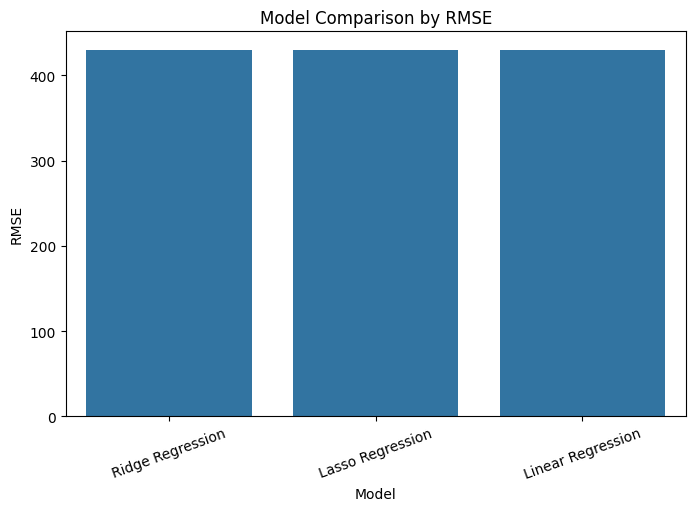

In [20]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="Model", y="RMSE")
plt.title("Model Comparison by RMSE")
plt.xticks(rotation=20)
plt.show()

## Cross Validation

I used TimeSeriesSplit because this dataset has time order.

In [21]:
tscv = TimeSeriesSplit(n_splits=5)
cv_rows = []

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    scores = -cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=tscv,
        scoring="neg_mean_squared_error"
    )
    
    cv_rows.append({
        "Model": name,
        "CV_RMSE": np.sqrt(scores).mean()
    })

cv_results = pd.DataFrame(cv_rows).sort_values("CV_RMSE")
cv_results

,Model,CV_RMSE
1,Ridge Regression,422.528461
2,Lasso Regression,422.991266
0,Linear Regression,423.009401


## Hyperparameter Tuning

GridSearchCV is used to tune alpha values for Ridge and Lasso.

In [22]:
ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge())
])

lasso_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(max_iter=20000))
])

ridge_grid = GridSearchCV(
    ridge_pipeline,
    {"model__alpha": [0.01, 0.1, 1, 10, 100]},
    cv=tscv,
    scoring="neg_mean_squared_error"
)

lasso_grid = GridSearchCV(
    lasso_pipeline,
    {"model__alpha": [0.001, 0.01, 0.1, 1, 10]},
    cv=tscv,
    scoring="neg_mean_squared_error"
)

ridge_grid.fit(X_train, y_train)
lasso_grid.fit(X_train, y_train)

print("Best Ridge Parameters:", ridge_grid.best_params_)
print("Best Lasso Parameters:", lasso_grid.best_params_)

Best Ridge Parameters: {'model__alpha': 1}
Best Lasso Parameters: {'model__alpha': 10}


In [23]:
tuned_models = {
    "Ridge Tuned": ridge_grid.best_estimator_,
    "Lasso Tuned": lasso_grid.best_estimator_
}

for name, model in tuned_models.items():
    pred = model.predict(X_test)
    predictions[name] = pred
    trained_models[name] = model
    
    row = {"Model": name}
    row.update(calculate_metrics(y_test, pred))
    results.append(row)

final_results = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
final_results

,Model,MAE,MSE,RMSE,R2
0,Lasso Tuned,353.671647,184051.991707,429.012811,0.986253
1,Ridge Regression,354.295996,184839.906674,429.930118,0.986194
2,Ridge Tuned,354.295996,184839.906674,429.930118,0.986194
3,Lasso Regression,354.290081,184879.985003,429.976726,0.986191
4,Linear Regression,354.311163,184893.965597,429.992983,0.986190


## Best Model

In [24]:
best_model_name = final_results.loc[0, "Model"]
best_model = trained_models[best_model_name]
best_pred = predictions[best_model_name]

print("Best Model:", best_model_name)
print(calculate_metrics(y_test, best_pred))

Best Model: Lasso Tuned
{'MAE': 353.6716470510438, 'MSE': 184051.99170727166, 'RMSE': np.float64(429.01281065636215), 'R2': 0.9862528239701889}


## Actual vs Predicted Plot

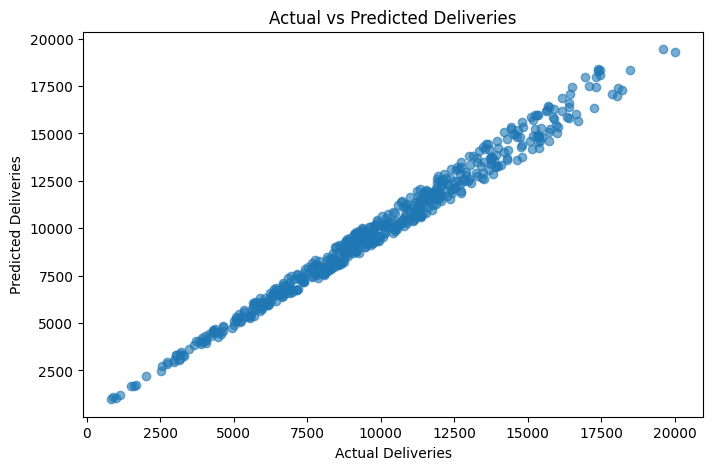

In [25]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, best_pred, alpha=0.6)
plt.title("Actual vs Predicted Deliveries")
plt.xlabel("Actual Deliveries")
plt.ylabel("Predicted Deliveries")
plt.show()

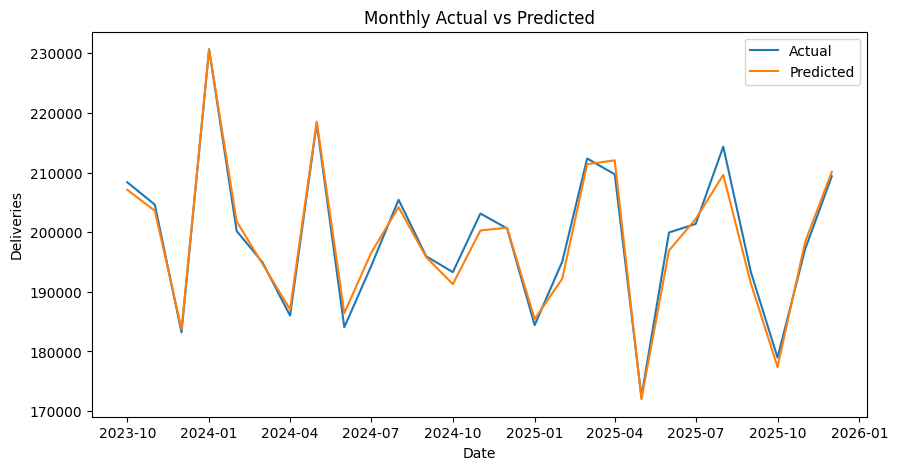

In [26]:
test_df = df.loc[test_mask].copy()
test_df["Predicted"] = best_pred

monthly_test = test_df.groupby("Date")[["Estimated_Deliveries", "Predicted"]].sum()

plt.figure(figsize=(10, 5))
plt.plot(monthly_test.index, monthly_test["Estimated_Deliveries"], label="Actual")
plt.plot(monthly_test.index, monthly_test["Predicted"], label="Predicted")
plt.title("Monthly Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Deliveries")
plt.legend()
plt.show()

## Time Series Components and Stationarity

Time series data can have trend, seasonality and noise.

Stationarity means the average and variation stay mostly stable over time. I checked this visually with rolling mean and rolling standard deviation.

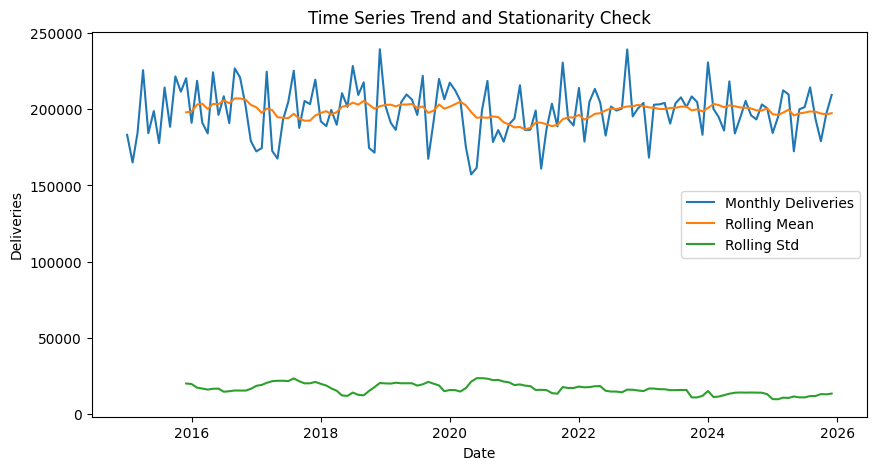

In [27]:
monthly = df.groupby("Date")["Estimated_Deliveries"].sum().reset_index()
monthly["Rolling_Mean_12"] = monthly["Estimated_Deliveries"].rolling(12).mean()
monthly["Rolling_Std_12"] = monthly["Estimated_Deliveries"].rolling(12).std()

plt.figure(figsize=(10, 5))
plt.plot(monthly["Date"], monthly["Estimated_Deliveries"], label="Monthly Deliveries")
plt.plot(monthly["Date"], monthly["Rolling_Mean_12"], label="Rolling Mean")
plt.plot(monthly["Date"], monthly["Rolling_Std_12"], label="Rolling Std")
plt.title("Time Series Trend and Stationarity Check")
plt.xlabel("Date")
plt.ylabel("Deliveries")
plt.legend()
plt.show()

## Forecasting

For forecasting, I used monthly deliveries with lag features and rolling average.

In [28]:
monthly["Lag1"] = monthly["Estimated_Deliveries"].shift(1)
monthly["Lag2"] = monthly["Estimated_Deliveries"].shift(2)
monthly["Rolling3"] = monthly["Estimated_Deliveries"].shift(1).rolling(3).mean()
monthly["Month"] = monthly["Date"].dt.month

monthly_model = monthly.dropna().reset_index(drop=True)

X_ts = monthly_model[["Lag1", "Lag2", "Rolling3", "Month"]]
y_ts = monthly_model["Estimated_Deliveries"]

split_ts = int(len(monthly_model) * 0.8)

X_train_ts = X_ts.iloc[:split_ts]
X_test_ts = X_ts.iloc[split_ts:]
y_train_ts = y_ts.iloc[:split_ts]
y_test_ts = y_ts.iloc[split_ts:]

forecast_model = LinearRegression()
forecast_model.fit(X_train_ts, y_train_ts)

forecast = forecast_model.predict(X_test_ts)

forecast_rmse = np.sqrt(mean_squared_error(y_test_ts, forecast))
print("Forecast RMSE:", forecast_rmse)

Forecast RMSE: 13596.356821487369


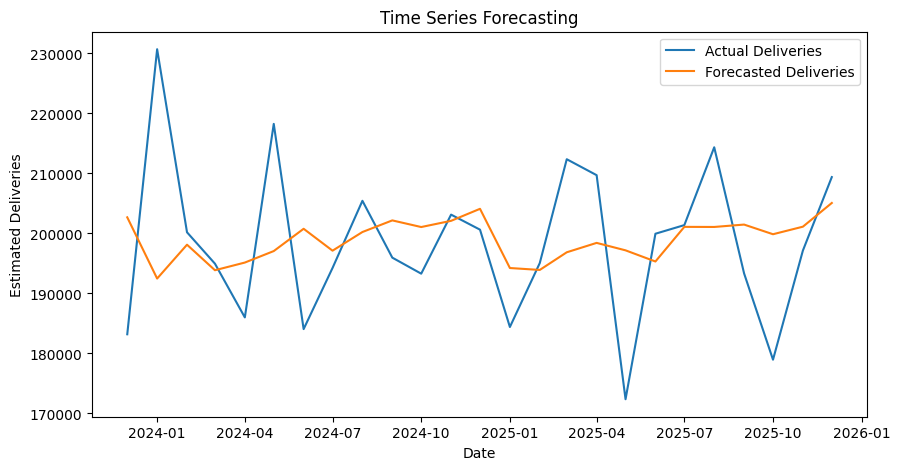

In [29]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_model.iloc[split_ts:]["Date"], y_test_ts, label="Actual Deliveries")
plt.plot(monthly_model.iloc[split_ts:]["Date"], forecast, label="Forecasted Deliveries")
plt.title("Time Series Forecasting")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.legend()
plt.show()

## Future Forecast

This is a simple forecast for the next 6 months.

In [30]:
history = monthly["Estimated_Deliveries"].tolist()
last_date = monthly["Date"].max()

future_dates = []
future_forecast = []

for i in range(1, 7):
    next_date = last_date + pd.DateOffset(months=i)
    
    next_row = pd.DataFrame({
        "Lag1": [history[-1]],
        "Lag2": [history[-2]],
        "Rolling3": [np.mean(history[-3:])],
        "Month": [next_date.month]
    })
    
    pred = forecast_model.predict(next_row)[0]
    future_dates.append(next_date)
    future_forecast.append(pred)
    history.append(pred)

future_df = pd.DataFrame({
    "Date": future_dates,
    "Forecasted_Deliveries": future_forecast
})

future_df

,Date,Forecasted_Deliveries
0,2026-01-01,195833.073049
1,2026-02-01,194082.195712
2,2026-03-01,195481.764646
3,2026-04-01,197057.580044
4,2026-05-01,197915.456139
5,2026-06-01,198593.053660


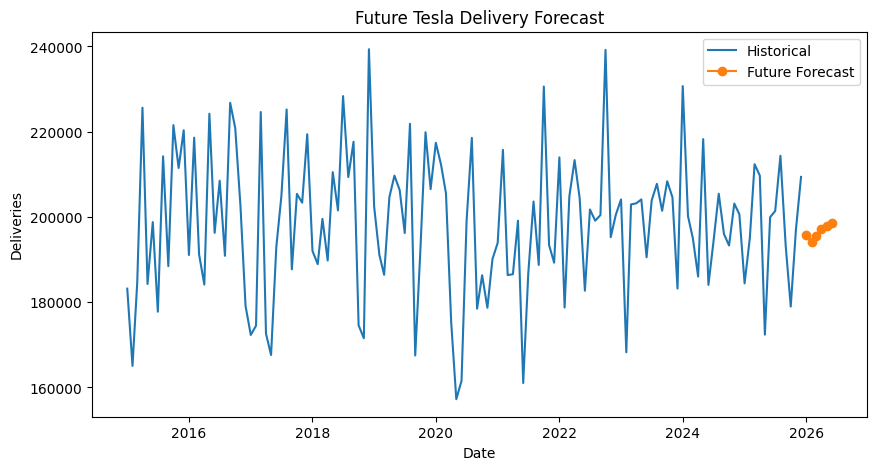

In [31]:
plt.figure(figsize=(10, 5))
plt.plot(monthly["Date"], monthly["Estimated_Deliveries"], label="Historical")
plt.plot(future_df["Date"], future_df["Forecasted_Deliveries"], marker="o", label="Future Forecast")
plt.title("Future Tesla Delivery Forecast")
plt.xlabel("Date")
plt.ylabel("Deliveries")
plt.legend()
plt.show()

## Forecasting Insights

The forecasting model uses past delivery values to estimate future deliveries.

This is a simple forecast, so in real life it should also use planned production and expected future prices.

# Conclusion

An end-to-end machine learning pipeline was completed on Tesla sales and production data.

The project demonstrated:
- Data cleaning
- Exploratory Data Analysis
- Feature engineering
- Encoding and scaling
- Linear, Ridge and Lasso Regression
- Cross validation
- Hyperparameter tuning
- Regression evaluation metrics
- Time series forecasting

The best regression model was selected using RMSE, and a basic future forecast was also created.